In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def setup_tridiagonal_matrix(x, y):
    
    n = len(x)
    
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1])) # Right-hand side vector
    
    return A, B, C, D


In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [4]:
def evaluate_spline(x_data, y_data):
    
    a, b, c, d = setup_tridiagonal_matrix(x_data, y_data)
    M = np.array([0.0, *thomas_algorithm(a, b, c, d), 0.0], dtype = float)
    length = 0
    for i in range(len(x_data)-1):
        length = length+((x_data[i+1]-x_data[i])*100)
    
    yspline = np.zeros(length)
    xspline = np.linspace(x_data[0], x_data[len(x_data)-1], length)
    
    for i in range(len(x_data)-1):
        x_interp = np.arange(x_data[i], x_data[i+1], 0.01)
        dxright = (x_data[i+1]-x_interp)
        dxleft = (x_interp-x_data[i])
        hi = x_data[i+1]-x_data[i]
        yspline[i*100:i*100+((x_data[i+1]-x_data[i])*100)] = (M[i]/(6*hi))*dxright**3 + \
        (M[i+1]/(6*hi))*dxleft**3 + (y_data[i]/hi-(M[i]*hi)/6)*dxright + \
        (y_data[i+1]/hi-(M[i+1]*hi)/6)*dxleft
        
    return xspline, yspline

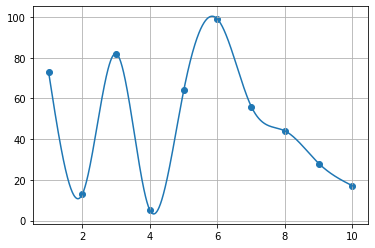

In [5]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([73, 13, 82, 5, 64, 99, 56, 44, 28, 17])
xplot, yplot = evaluate_spline(x, y)
plt.figure()
plt.grid()
plt.title('Cubic Spline Interpolatio')
plt.scatter(x, y)
plt.plot(xplot, yplot)
plt.show()